In [3]:
from google.colab import files

uploaded = files.upload()

Saving movie_titles.csv to movie_titles.csv


In [6]:
from google.colab import files

uploaded = files.upload()

Saving combined_data_1.txt to combined_data_1.txt


In [7]:
import os
print(os.listdir())

['.config', 'combined_data_1.txt', 'movie_titles.csv', 'sample_data']


In [9]:
import pandas as pd

movies = pd.read_csv(
    "movie_titles.csv",
    header=None,
    names=["Movie_ID", "Year", "Movie_Name"],
    encoding="latin-1",
    engine="python",
    on_bad_lines="skip"
)

movies.head()

,Movie_ID,Year,Movie_Name
0,1,2003.0,Dinosaur Planet
1,2,2004.0,Isle of Man TT 2004 Review
2,3,1997.0,Character
3,4,1994.0,Paula Abdul's Get Up & Dance
4,5,2004.0,The Rise and Fall of ECW


In [10]:
with open("combined_data_1.txt", "r") as f:
    for i in range(15):
        print(f.readline().strip())


1:
1488844,3,2005-09-06
822109,5,2005-05-13
885013,4,2005-10-19
30878,4,2005-12-26
823519,3,2004-05-03
893988,3,2005-11-17
124105,4,2004-08-05
1248029,3,2004-04-22
1842128,4,2004-05-09
2238063,3,2005-05-11
1503895,4,2005-05-19
2207774,5,2005-06-06
2590061,3,2004-08-12
2442,3,2004-04-14


In [11]:
import pandas as pd

movie_ids = []
customer_ids = []
ratings = []
dates = []

current_movie = None

with open("combined_data_1.txt", "r") as f:
    for line in f:
        line = line.strip()

        # Movie ID line
        if line.endswith(":"):
            current_movie = int(line[:-1])

        # Rating line
        else:
            customer, rating, date = line.split(",")

            movie_ids.append(current_movie)
            customer_ids.append(int(customer))
            ratings.append(int(rating))
            dates.append(date)

ratings_df = pd.DataFrame({
    "Movie_ID": movie_ids,
    "Customer_ID": customer_ids,
    "Rating": ratings,
    "Date": dates
})

ratings_df.head()

,Movie_ID,Customer_ID,Rating,Date
0,1,1488844,3,2005-09-06
1,1,822109,5,2005-05-13
2,1,885013,4,2005-10-19
3,1,30878,4,2005-12-26
4,1,823519,3,2004-05-03


In [12]:
ratings_df.info()

ratings_df.shape

ratings_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24053764 entries, 0 to 24053763
Data columns (total 4 columns):
 #   Column       Dtype 
---  ------       ----- 
 0   Movie_ID     int64 
 1   Customer_ID  int64 
 2   Rating       int64 
 3   Date         object
dtypes: int64(3), object(1)
memory usage: 734.1+ MB


,Movie_ID,Customer_ID,Rating,Date
0,1,1488844,3,2005-09-06
1,1,822109,5,2005-05-13
2,1,885013,4,2005-10-19
3,1,30878,4,2005-12-26
4,1,823519,3,2004-05-03


In [13]:
netflix = pd.merge(ratings_df, movies, on="Movie_ID")

netflix.head()

,Movie_ID,Customer_ID,Rating,Date,Year,Movie_Name
0,1,1488844,3,2005-09-06,2003.0,Dinosaur Planet
1,1,822109,5,2005-05-13,2003.0,Dinosaur Planet
2,1,885013,4,2005-10-19,2003.0,Dinosaur Planet
3,1,30878,4,2005-12-26,2003.0,Dinosaur Planet
4,1,823519,3,2004-05-03,2003.0,Dinosaur Planet


In [14]:
print(netflix.shape)

netflix.info()

netflix.describe()

(23807405, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23807405 entries, 0 to 23807404
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   Movie_ID     int64  
 1   Customer_ID  int64  
 2   Rating       int64  
 3   Date         object 
 4   Year         float64
 5   Movie_Name   object 
dtypes: float64(1), int64(3), object(2)
memory usage: 1.1+ GB


,Movie_ID,Customer_ID,Rating,Year
count,2.380740e+07,2.380740e+07,2.380740e+07,2.380722e+07
mean,2.305687e+03,1.322278e+06,3.596893e+00,1.994508e+03
std,1.307075e+03,7.645835e+05,1.085834e+00,1.254453e+01
min,1.000000e+00,6.000000e+00,1.000000e+00,1.915000e+03
25%,1.180000e+03,6.608710e+05,3.000000e+00,1.991000e+03
50%,2.337000e+03,1.318608e+06,4.000000e+00,1.999000e+03
75%,3.434000e+03,1.984352e+06,4.000000e+00,2.003000e+03
max,4.499000e+03,2.649429e+06,5.000000e+00,2.005000e+03


In [15]:
netflix.isnull().sum()

,0
Movie_ID,0
Customer_ID,0
Rating,0
Date,0
Year,189
Movie_Name,0


In [16]:
top_movies = (
    netflix.groupby("Movie_Name")["Rating"]
    .count()
    .sort_values(ascending=False)
    .head(10)
)

print(top_movies)

Movie_Name
Pirates of the Caribbean: The Curse of the Black Pearl    193941
What Women Want                                           162597
Bruce Almighty                                            160454
The Italian Job                                           156183
American Beauty                                           154832
Shrek 2                                                   153996
The Sixth Sense                                           151292
Lord of the Rings: The Fellowship of the Ring             149866
50 First Dates                                            145519
Finding Nemo (Widescreen)                                 140979
Name: Rating, dtype: int64


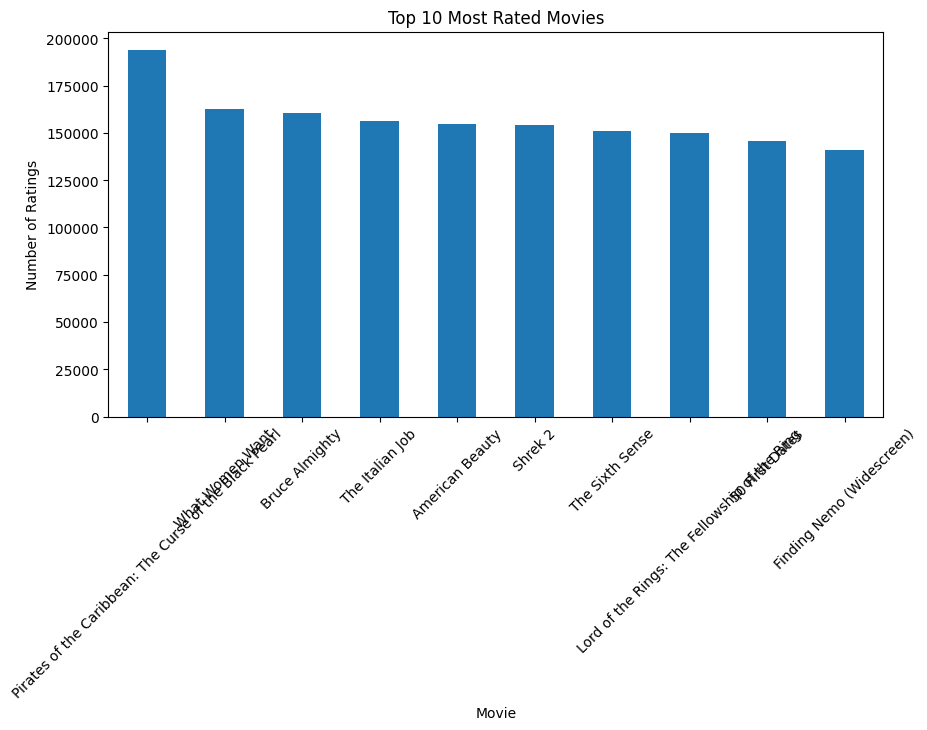

In [17]:
import matplotlib.pyplot as plt

top_movies.plot(kind="bar", figsize=(10,5))

plt.title("Top 10 Most Rated Movies")
plt.xlabel("Movie")
plt.ylabel("Number of Ratings")

plt.xticks(rotation=45)

plt.show()

In [18]:
average_rating = netflix.groupby("Movie_Name")["Rating"].mean().sort_values(ascending=False)

average_rating.head(10)

,Rating
Movie_Name,
Lost: Season 1,4.670989
Ghost in the Shell: Stand Alone Complex: 2nd Gig,4.586364
The Simpsons: Season 6,4.581296
Inu-Yasha,4.554434
Lord of the Rings: The Return of the King: Extended Edition: Bonus Material,4.552000
Family Guy: Freakin' Sweet Collection,4.516007
The West Wing: Season 3,4.473692
Six Feet Under: Season 4,4.469693
Samurai Champloo,4.467500


In [19]:
rating_count = netflix.groupby("Movie_Name")["Rating"].count()

rating_count.head()

,Rating
Movie_Name,
'N Sync: 'N the Mix,497
'N Sync: PopOdyssey Live,92
... And God Spoke,180
10,4928
10 Minute Solution: Pilates,163


In [20]:
movie_stats = pd.DataFrame({
    "Average_Rating": average_rating,
    "Number_of_Ratings": rating_count
})

movie_stats.head()

,Average_Rating,Number_of_Ratings
Movie_Name,,
'N Sync: 'N the Mix,2.655936,497
'N Sync: PopOdyssey Live,3.413043,92
... And God Spoke,2.872222,180
10,3.127638,4928
10 Minute Solution: Pilates,3.171779,163


In [21]:
top_rated = movie_stats[movie_stats["Number_of_Ratings"] >= 50]

top_rated = top_rated.sort_values("Average_Rating", ascending=False)

top_rated.head(10)

,Average_Rating,Number_of_Ratings
Movie_Name,,
Lost: Season 1,4.670989,7249
Ghost in the Shell: Stand Alone Complex: 2nd Gig,4.586364,220
The Simpsons: Season 6,4.581296,8426
Inu-Yasha,4.554434,1883
Lord of the Rings: The Return of the King: Extended Edition: Bonus Material,4.552000,125
Family Guy: Freakin' Sweet Collection,4.516007,10027
The West Wing: Season 3,4.473692,6633
Six Feet Under: Season 4,4.469693,11829
Samurai Champloo,4.467500,2000


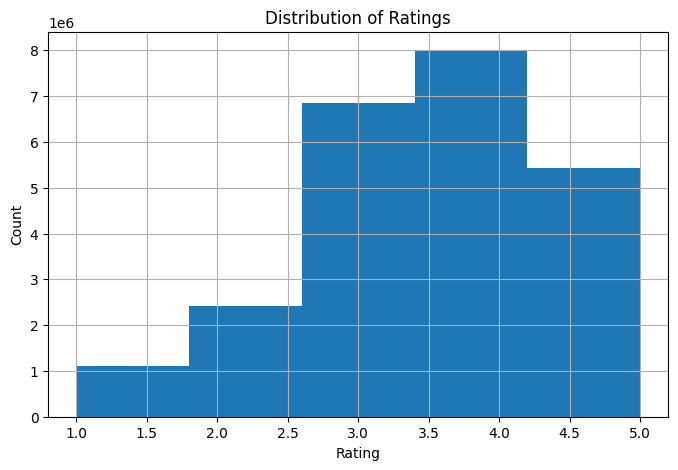

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

netflix["Rating"].hist(bins=5)

plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.show()

In [23]:
active_users = netflix["Customer_ID"].value_counts().head(10)

print(active_users)

Customer_ID
305344     4382
387418     4337
2439493    4115
1664010    3940
2118461    3695
1639792    2443
1314869    2433
1461435    2398
1932594    2229
2606799    2201
Name: count, dtype: int64


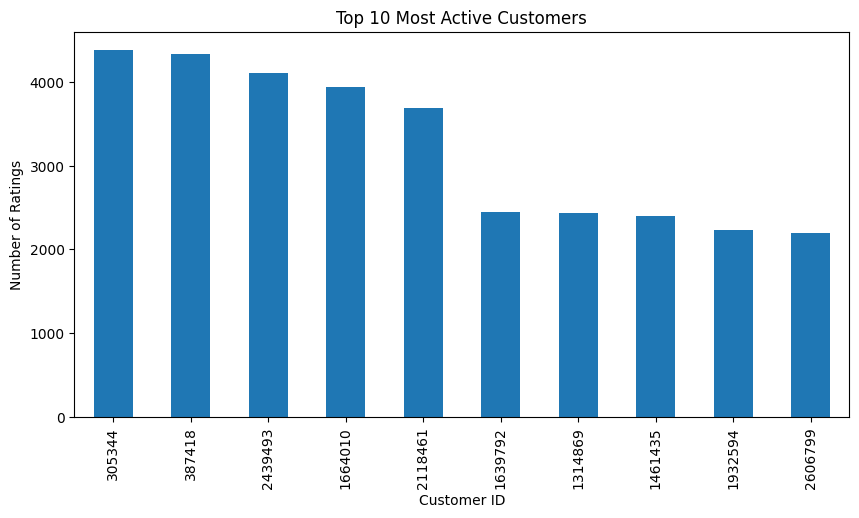

In [24]:
active_users.plot(kind="bar", figsize=(10,5))

plt.title("Top 10 Most Active Customers")
plt.xlabel("Customer ID")
plt.ylabel("Number of Ratings")

plt.show()

In [25]:
movie_name = "Dinosaur Planet"

netflix[netflix["Movie_Name"] == movie_name].head()

,Movie_ID,Customer_ID,Rating,Date,Year,Movie_Name
0,1,1488844,3,2005-09-06,2003.0,Dinosaur Planet
1,1,822109,5,2005-05-13,2003.0,Dinosaur Planet
2,1,885013,4,2005-10-19,2003.0,Dinosaur Planet
3,1,30878,4,2005-12-26,2003.0,Dinosaur Planet
4,1,823519,3,2004-05-03,2003.0,Dinosaur Planet


In [26]:
def recommend_movies(n=10):
    return movie_stats.sort_values(
        by=["Average_Rating", "Number_of_Ratings"],
        ascending=False
    ).head(n)

recommend_movies()

,Average_Rating,Number_of_Ratings
Movie_Name,,
Lost: Season 1,4.670989,7249
Ghost in the Shell: Stand Alone Complex: 2nd Gig,4.586364,220
The Simpsons: Season 6,4.581296,8426
Inu-Yasha,4.554434,1883
Lord of the Rings: The Return of the King: Extended Edition: Bonus Material,4.552000,125
Family Guy: Freakin' Sweet Collection,4.516007,10027
The West Wing: Season 3,4.473692,6633
Six Feet Under: Season 4,4.469693,11829
Samurai Champloo,4.467500,2000


In [ ]:
!pip -q install scikit-surprise

In [ ]:
from surprise import Dataset, Reader
reader=Reader(rating_scale=(1,5))
data=Dataset.load_from_df(ratings_df[['Customer_ID','Movie_ID','Rating']], reader)
print('Dataset loaded for Surprise.')

In [ ]:
from surprise.model_selection import train_test_split
from surprise import SVD, accuracy
trainset,testset=train_test_split(data,test_size=0.2,random_state=42)
svd_model=SVD(random_state=42)
svd_model.fit(trainset)
predictions=svd_model.test(testset)
accuracy.rmse(predictions)

In [ ]:
user_id=int(ratings_df['Customer_ID'].iloc[0])
rated_movies=set(ratings_df.loc[ratings_df['Customer_ID']==user_id,'Movie_ID'])
unrated=[m for m in movies['Movie_ID'].unique() if m not in rated_movies]
preds=[]
for mid in unrated:
    preds.append((mid,svd_model.predict(user_id,mid).est))
preds=sorted(preds,key=lambda x:x[1],reverse=True)[:5]
print('Top 5 Movie Recommendations')
for mid,score in preds:
    title=movies.loc[movies['Movie_ID']==mid,'Movie_Name'].values[0]
    print(f'{title} -> Estimated Score: {score:.2f}')